# E-commerce Data Analysis Project
## 1. Introduction and Setup
In this project, we analyze an e-commerce dataset to extract meaningful insights about sales, profitability, and customer behavior.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading and Inspection
Let's load the dataset and take a quick look at the first few rows, as well as the data types and missing values.

In [2]:
# Load Dataset
df = pd.read_csv('ecommerce.csv', encoding='latin1')

# Display First Rows
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub_category,product_name,sales,quantity,discount,profit,returned,person_region
0,1,CA-2014-103800,2018-01-03,2018-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,NaN,Kelly Williams
1,2,CA-2014-112326,2018-01-04,2018-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,NaN,Kelly Williams
2,3,CA-2014-112326,2018-01-04,2018-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,NaN,Kelly Williams
3,4,CA-2014-112326,2018-01-04,2018-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,NaN,Kelly Williams
4,5,CA-2014-141817,2018-01-05,2018-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,NaN,Chuck Magee


In [3]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   order_date     9994 non-null   str    
 3   ship_date      9994 non-null   str    
 4   ship_mode      9994 non-null   str    
 5   customer_id    9994 non-null   str    
 6   customer_name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   str    
 13  product_id     9994 non-null   str    
 14  category       9994 non-null   str    
 15  sub_category   9994 non-null   str    
 16  product_name   9994 non-null   str    
 17  sales          9994 non-null   float64
 18  quantity       9994

In [4]:
# Check for Null Values
df.isnull().sum()

row_id              0
order_id            0
order_date          0
ship_date           0
ship_mode           0
customer_id         0
customer_name       0
segment             0
country             0
city                0
state               0
postal_code         0
region              0
product_id          0
category            0
sub_category        0
product_name        0
sales               0
quantity            0
discount            0
profit              0
returned         9194
person_region       0
dtype: int64

## 3. Key Performance Indicators (KPIs)
We will calculate the basic KPIs such as Total Sales, Total Profit, and Total Orders to understand the overall business performance.

In [5]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009


## 4. Exploratory Data Analysis (EDA)
### 4.1 Sales by Category
Let's see which categories generate the most revenue.

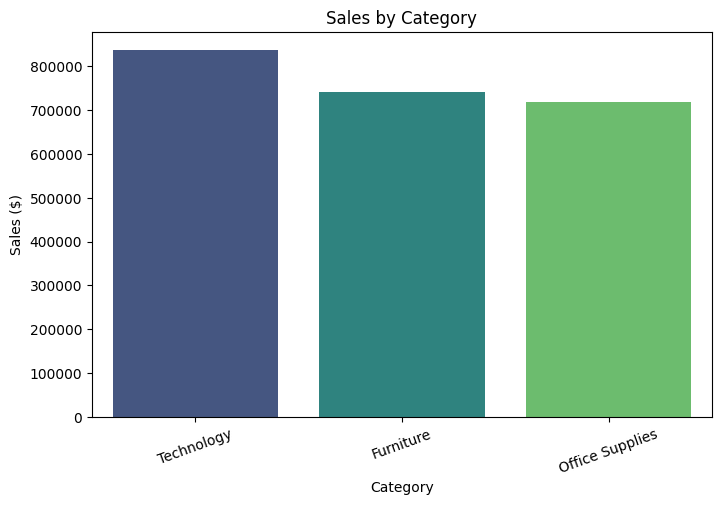

In [6]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=20)
plt.show()

### 4.2 Monthly Sales Trend
Understanding the seasonality of sales is crucial for inventory and marketing planning.

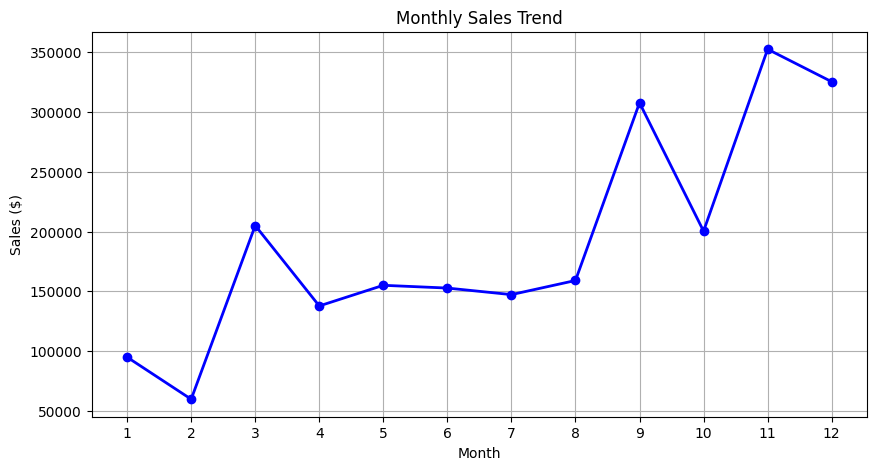

In [7]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['Month'] = df['order_date'].dt.month

monthly_sales = df.groupby('Month')['sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o', color='b', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1, 13))
plt.grid()
plt.show()

### 4.3 Region-wise Profit
Which regions are the most profitable?

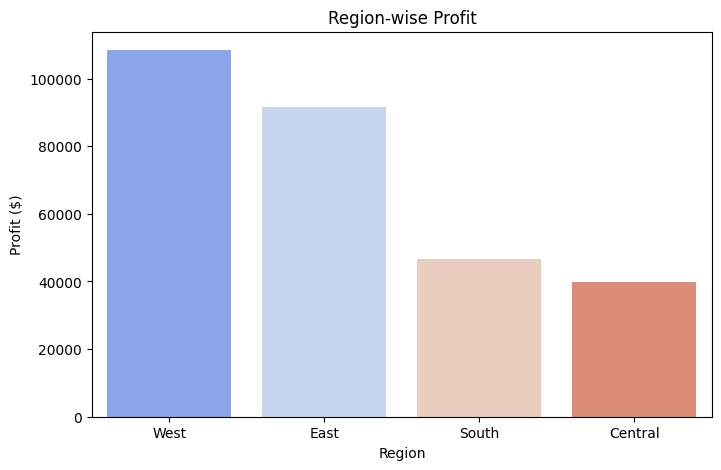

In [8]:
region_profit = df.groupby('region')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_profit.index, y=region_profit.values, palette='coolwarm')
plt.title('Region-wise Profit')
plt.xlabel('Region')
plt.ylabel('Profit ($)')
plt.show()

### 4.4 Top 10 Best Selling Products
Identifying top-performing products.

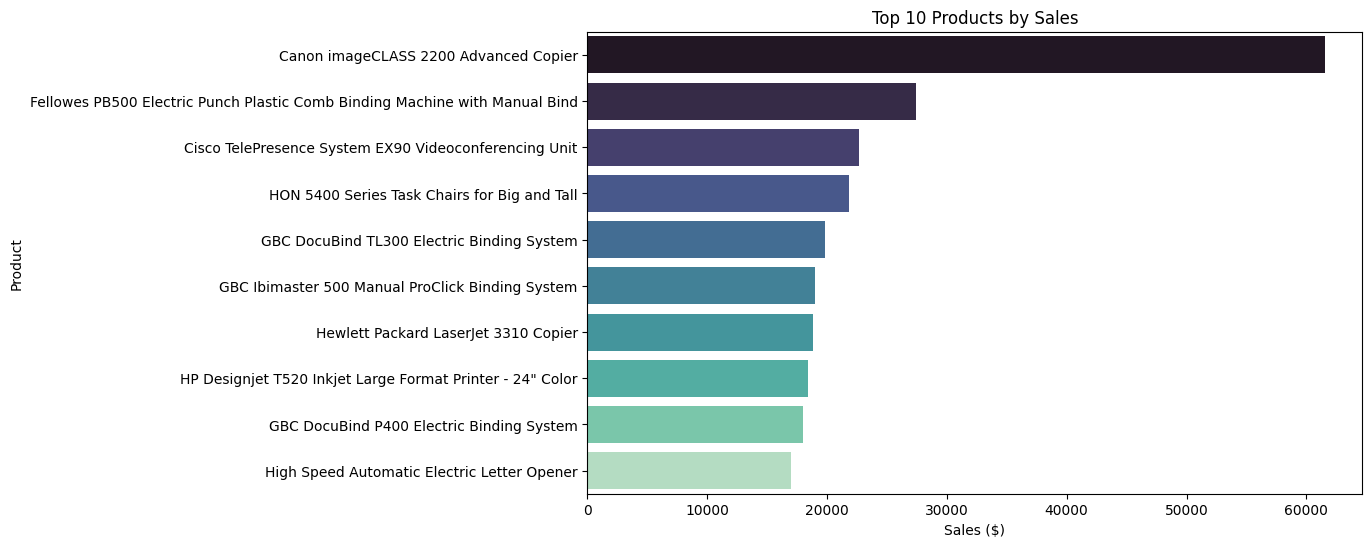

In [9]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette='mako')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Product')
plt.show()

### 4.5 Impact of Discount on Profit
Do higher discounts lead to lower profits?

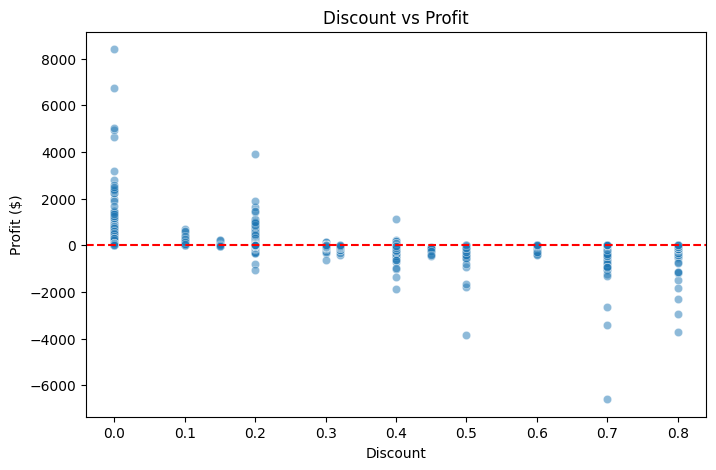

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['discount'], y=df['profit'], alpha=0.5)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(0, color='red', linestyle='--') # highlighting the 0 profit line
plt.show()

## 5. Data Export
Saving the cleaned and transformed dataset for further use.

In [11]:
df.to_csv('cleaned_ecommerce.csv', index=False)
print("Cleaned dataset saved successfully to 'cleaned_ecommerce.csv'")

Cleaned dataset saved successfully to 'cleaned_ecommerce.csv'
